# 04b — Red neuronal (tarea 10)

- Features temporales (lags, deltas)
- Codificación cíclica de hora/día/mes
- Features de interacción
- Scaler ajustado solo en train
- MLP (ReLU, sin conexión residual)
- Focal Loss
- Adam (lr fijo 1e-3)
- Early stopping
- Optimización del umbral de clasificación

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import joblib
import os

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('../data/gold/dataset_tarea9_final.csv', index_col=0, parse_dates=True)
df = df.sort_index()

for lag in [1, 2, 3]:
    df[f'temp_aula_lag{lag}'] = df['temp_aula'].shift(lag)
    df[f'temp_exterior_lag{lag}'] = df['temp_exterior'].shift(lag)
    df[f'calefaccion_lag{lag}'] = df['calefaccion_encendida'].shift(lag)

df['delta_temp_aula_1h'] = df['temp_aula'] - df['temp_aula'].shift(1)
df['delta_temp_aula_2h'] = df['temp_aula'] - df['temp_aula'].shift(2)
df['delta_temp_exterior_1h'] = df['temp_exterior'] - df['temp_exterior'].shift(1)

df['hora_sin'] = np.sin(2 * np.pi * df['hora_del_dia'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_del_dia'] / 24)
df['dia_sin'] = np.sin(2 * np.pi * df['dia_de_la_semana'] / 7)
df['dia_cos'] = np.cos(2 * np.pi * df['dia_de_la_semana'] / 7)
df['mes_sin'] = np.sin(2 * np.pi * df['mes_del_ano'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes_del_ano'] / 12)

df['diff_temp'] = df['temp_aula'] - df['temp_exterior']
df['calef_x_diff'] = df['calefaccion_encendida'] * df['diff_temp']
df['calef_x_viento'] = df['calefaccion_encendida'] * df['vel_viento']

df = df.dropna()

FEATURE_COLS = [
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos',
    'temp_aula', 'hum_aula', 'pres_aula',
    'temp_exterior', 'nubosidad', 'hum_exterior', 'vel_viento',
    'elevacion_sol', 'acimut_sol',
    'calefaccion_encendida',
    'temp_aula_lag1', 'temp_aula_lag2', 'temp_aula_lag3',
    'temp_exterior_lag1', 'temp_exterior_lag2', 'temp_exterior_lag3',
    'calefaccion_lag1', 'calefaccion_lag2', 'calefaccion_lag3',
    'delta_temp_aula_1h', 'delta_temp_aula_2h', 'delta_temp_exterior_1h',
    'diff_temp', 'calef_x_diff', 'calef_x_viento',
]
TARGET_COL = 'derroche_siguiente_hora'

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.int64)

print(f"Muestras: {len(X)}, Features: {X.shape[1]}")
print(f"Derroche sí: {y.sum()}, Derroche no: {len(y) - y.sum()} ({y.mean():.2%})")

Muestras: 3921, Features: 31
Derroche sí: 1056, Derroche no: 2865 (26.93%)


In [3]:
n_total = len(X)
idx = np.arange(n_total)
idx_train, idx_temp = train_test_split(idx, test_size=0.3, shuffle=False)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, shuffle=False)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[idx_train])
X_val = scaler.transform(X[idx_val])
X_test = scaler.transform(X[idx_test])

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Derroche en test: {y_test.sum()} ({y_test.mean():.2%})")

Train: 2744, Val: 588, Test: 589
Derroche en test: 158 (26.83%)


In [4]:
class DerrocheDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_ds = DerrocheDataset(X_train, y_train)
val_ds = DerrocheDataset(X_val, y_val)
test_ds = DerrocheDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [17]:
class RedDerrocheV2(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn3 = nn.BatchNorm1d(hidden_dim // 2)
        self.classifier = nn.Linear(hidden_dim // 2, 1)
        self.drop = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RedDerrocheV2(input_dim=X_train.shape[1]).to(device)
print(f"Device: {device}")
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Parámetros: 29,569


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().ravel())
            all_targets.extend(y_batch.numpy().ravel().astype(int))
    return np.array(all_probs), np.array(all_targets)

def find_best_threshold(probs, targets):
    best_thr, best_f1 = 0.5, 0
    for thr in np.arange(0.20, 0.80, 0.01):
        preds = (probs >= thr).astype(int)
        f = f1_score(targets, preds, zero_division=0)
        if f > best_f1:
            best_thr, best_f1 = thr, f
    return best_thr, best_f1

In [13]:
EPOCHS = 500
PATIENCE = 40
best_val_f1 = 0
epochs_no_improve = 0
history = {'train_loss': [], 'val_f1': []}

os.makedirs('../models', exist_ok=True)

for epoch in range(EPOCHS):
    loss = train_epoch(model, train_loader, criterion, optimizer, device)
    prob_val, y_val_true = evaluate(model, val_loader, device)
    thr, val_f1 = find_best_threshold(prob_val, y_val_true)

    history['train_loss'].append(loss)
    history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_thr = thr
        epochs_no_improve = 0
        torch.save(model.state_dict(), '../models/model_derroche_v2_best.pt')
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 20 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Val F1: {val_f1:.4f} (thr={thr:.2f}) - LR: {lr_now:.6f}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping en epoch {epoch+1}, best Val F1: {best_val_f1:.4f}")
        break

print(f"\nMejor Val F1: {best_val_f1:.4f} con umbral: {best_thr:.2f}")

Epoch 20/500 - Loss: 0.0076 - Val F1: 0.9528 (thr=0.44) - LR: 0.001000
Epoch 40/500 - Loss: 0.0060 - Val F1: 0.9476 (thr=0.42) - LR: 0.001000
Epoch 60/500 - Loss: 0.0053 - Val F1: 0.9648 (thr=0.47) - LR: 0.001000
Epoch 80/500 - Loss: 0.0040 - Val F1: 0.9587 (thr=0.42) - LR: 0.001000
Early stopping en epoch 96, best Val F1: 0.9667

Mejor Val F1: 0.9667 con umbral: 0.50


In [14]:
model.load_state_dict(torch.load('../models/model_derroche_v2_best.pt', map_location=device))
prob_test, y_test_true = evaluate(model, test_loader, device)
pred_test = (prob_test >= best_thr).astype(int)

accuracy = accuracy_score(y_test_true, pred_test)
precision = precision_score(y_test_true, pred_test, zero_division=0)
recall = recall_score(y_test_true, pred_test, zero_division=0)
f1 = f1_score(y_test_true, pred_test, zero_division=0)
roc_auc = roc_auc_score(y_test_true, prob_test) if y_test_true.sum() > 0 else 0

print(f"Test (umbral={best_thr:.2f})")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"\nMatriz de confusión:")
print(confusion_matrix(y_test_true, pred_test))
print(f"\nClassification report:")
print(classification_report(y_test_true, pred_test, target_names=['No derroche', 'Derroche']))

Test (umbral=0.50)
Accuracy:  0.8981
Precision: 0.7450
Recall:    0.9430
F1-Score:  0.8324
ROC-AUC:   0.9627

Matriz de confusión:
[[380  51]
 [  9 149]]

Classification report:
              precision    recall  f1-score   support

 No derroche       0.98      0.88      0.93       431
    Derroche       0.74      0.94      0.83       158

    accuracy                           0.90       589
   macro avg       0.86      0.91      0.88       589
weighted avg       0.91      0.90      0.90       589



In [15]:
pred_test_default = (prob_test >= 0.5).astype(int)
f1_default = f1_score(y_test_true, pred_test_default, zero_division=0)

print(f"F1 con umbral 0.50: {f1_default:.4f}")
print(f"F1 con umbral {best_thr:.2f}: {f1:.4f}")
print(f"Ganancia por optimización de umbral: +{f1 - f1_default:.4f}")

F1 con umbral 0.50: 0.8324
F1 con umbral 0.50: 0.8324
Ganancia por optimización de umbral: +0.0000


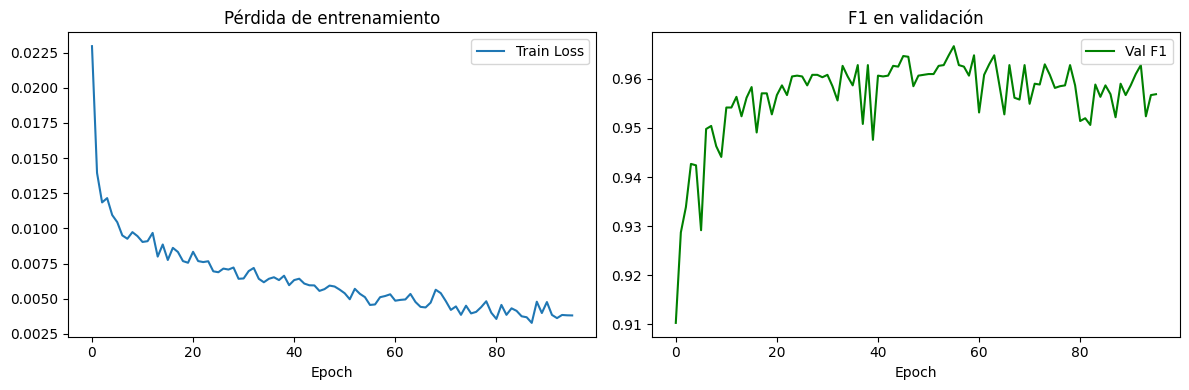

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].set_title('Pérdida de entrenamiento')
axes[1].plot(history['val_f1'], label='Val F1', color='green')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].set_title('F1 en validación')
plt.tight_layout()
plt.show()

In [14]:
model.load_state_dict(torch.load('../models/model_derroche_v2_best.pt', map_location=device))
torch.save({
    'model_state': model.state_dict(),
    'input_dim': X_train.shape[1],
    'hidden_dim': 128,
    'feature_cols': FEATURE_COLS,
    'best_threshold': best_thr,
}, '../models/model_derroche_v2.pt')
joblib.dump(scaler, '../models/scaler_derroche_v2.joblib')
print("Checkpoint v2 guardado en models/")

Checkpoint v2 guardado en models/


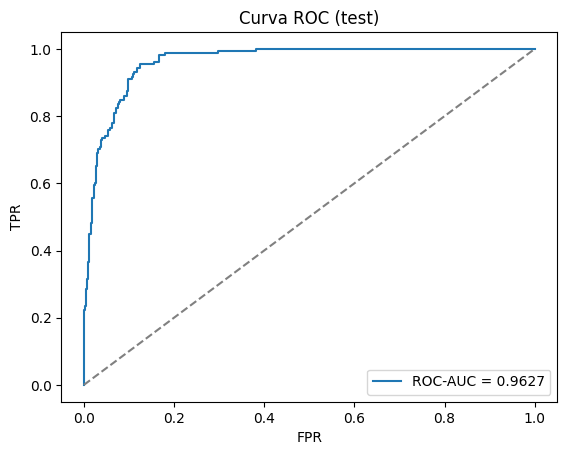

In [18]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test_true, prob_test)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC (test)')
plt.legend(); plt.show()